In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Simulation
Solve the dynamics
$$\partial_t h = \partial_x Q \partial_x \Pi$$
$$\Pi = -\Delta h+\partial_h W$$
$$Q=h^3/3\eta$$
$$W=A(\chi)w(h);\quad \chi = \epsilon x$$
$$w(h)=h_a^3\frac15 h^{-5}-\frac12 h^{-2}$$

There is no bulk force ($c=0$), while
$$A=A_0+\nabla_{\chi}A \cdot \chi$$
And the inhomogenity is activated at time $t>t_0$, through the activation function $$\theta(t)=\frac12 \{1+\tanh((t-t_0)\sigma^{-1})\};$$
 to leave the system the time to converge to the equilibrium state from the initial condition. In the present simulation

In [2]:
# Parameters of the simulation
eps = 0.001
ha = 0.5

eta = 1
A0 = 1
grad_chiA = 1

t0 = 1e3    # At this time driving is turned ON
def A(x):
    return A0+grad_chiA*float(eps)*x

In [ ]:
# Simulation (call the time solver)
%run -i time_solver.py $eps

OUTPUT WILL BE WRITTEN TO time_solver
Removing contents of output dir
SOLVING THE FOLLOWING SYSTEM:
/
|--domain : Combined Equations:
|            ThinfilmEquation
|            TextFileOutput
|            InitialCondition: h=1+(0.5)*cos((0.25132741228718344929)*field(coordinate_x,< code=0 , tags=>))
|            SpatialErrorEstimator: h
|            IntegralObservables
|            IntegralObservableOutput
Generating equation C code: time_solver/_ccode/domain
Compiling equation C code
BUILDING GLOBAL MESH FROM LIST
Number of equations: 4002
SETTING IC 
Max. error in binNumber of equations: 4002
Initial adaption: 0 of 1
ary tree neighbour finding: 0 is OK
i.e. less than BinaryTree::max_neighbour_finding_tolerance()=1e-14
IN MESH domain ref= 0 unref= 0
REBUILDING GLOBAL MESH
 
 Number of elements to be refinNumber of equations: 4002
Number of equations: 4002
REBUILDING GLOBAL MESH FROM LIST
Number of equations: 4002
PROBLEM IS NOW INITIALIZED
Following solvers will be used:
    Sparse Ma

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4344/3519781589.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\partial_h W_0^{out}$')
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4344/3147132741.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon (t-t_0)$')
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4344/3903282327.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon (t-t_0)$')
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4344/3444105433.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon (t-t_0)$')
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4344/388683680

In [4]:
# Read hmax(t) and xmax(t) from domain*.txt

import glob
files = sorted(glob.glob("time_solver/domain/domain_*.txt"))

times = []
h_max_list = []
x_at_hmax = []

for file in files:
    # --- Read header line ---
    with open(file, "r") as f:
        header = f.readline()
    
    # Extract time
    # "# coordinate_x h p @time=353.0"
    time_val = float(header.split("@time=")[-1])
    
    # --- Read data with numpy ---
    data = np.loadtxt(file)   # automatically skips lines starting with '#'
    data = np.atleast_2d(data)
    
    x = data[:, 0]
    h = data[:, 1]
    
    # --- Find maximum ---
    idx = np.argmax(h)
    
    times.append(time_val)
    h_max_list.append(h[idx])
    x_at_hmax.append(x[idx])

# Convert to arrays
times = np.array(times)
h_max_list = np.array(h_max_list)
x_at_hmax = np.array(x_at_hmax)

In [5]:
# Read grad_x h0out(t) from obx.txt
time, grad_x_h0out = np.loadtxt(
    "time_solver/obs.txt",
    skiprows=1,
    unpack=True
)

# Measure $h_0^{out}$ from $h_{max}$

In the absence of driving and in the limit of large droplets, where $h_0^{out}=h_a+\delta h_0^{out}$
$$\delta h_0^{out}= \frac{w(h_{max})-w(h_a)}{h_{max}-h_a}w''(h_a)^{-1}+O((\delta h_0^{out})^2)$$
And as in this limit
$$\partial_h W_0^{out}=A(\chi_*)w''(h_a)\delta h_0^{out}+O((\delta h_0^{out})^2)$$
$$\partial_h W_0^{out}=A(\chi_*)\frac{w(h_{max})-w(h_a)}{h_{max}-h_a}$$
$$\partial_h W_0^{out}(A(\chi_*), h_0^{out})$$

For $\nabla_{\chi}h_0^{out}$, this is the same on both sides of the droplet and so we measure it during the time simulation. We use a test function $\phi$ that is 1 close to the boundaries and zero outside, such that $\int h(x)\phi(x) dx \alpha \nabla_{\chi}h_0^{out}$ where the multiplication factor is the support of $\phi$. 

In [6]:
# Compute h0out and dWh0out
def wetting_pot(h):
        return (ha**3/5*h**(-5) - 1/2*h**(-2))
def dwetting_pot(h):
        return (- ha**3*h**(-6) + h**(-3))
def ddwetting_pot(h):
        return (7*ha**3*h**(-7) - 3*h**(-4))
h0outs = ha + (wetting_pot(h_max_list)-wetting_pot(ha))/(h_max_list-ha)*(1/(ddwetting_pot(ha)))
As=A(x_at_hmax)

dW0outs = A(x_at_hmax)*(wetting_pot(h_max_list)-wetting_pot(ha))/(h_max_list-ha) #h0in is paramterized by this number only!

# Solve $h_0^{in}$ from $h_0^{out}$ (for each time-step)
As I cannot find the non-trivial (droplet) solution by solving (with sol of pyoomph)
$$-\Delta h_0^{in} +\partial_h W_0^{in} = \partial_h W_0^{out}$$
$$\partial_h W_0^{in} = A(\chi_*)w'(h_0^{in});\quad \partial_h W_0^{out}=A(\chi_*)w''(h_a)\delta h_0^{out}+o.s.$$
I look for the stationary states of 
$$-\Delta h_0^{in}+\partial_h W_0^{in} = 0$$
with a mass constrain, that is equivalent to solve the previous equation where $\partial_h W_0^{out}$ is the **Lagrange multiplier** for the mass

$$m=\int h_0^{in} dx$$

-----------

**Notice**: $A(\chi_*)=A_0+\nabla_{\chi}A\chi_*$ but as the equation is obtained neglecting terms $O(\epsilon)$, we consider $\partial_h W_0^{in}=A_0w'(h_0^{in})$ to be consistent. Then the only parameter appearing in the equation is the RH side, so $h_0^{in}(\partial_h W_0^{out})$, where $\partial_h W_0^{out}$ is a **number**.

**Extra**: In this way, we compute $h_0^{in}(\partial_h W_0^{out})$ for $A_0=1$, for a generic value of $A(\chi_*)$ we do not need to solve again the eq. for h0in, we can use the results for $A_0=1$ and change variable $x'=A(\chi_*)^{1/2}x$, so
$$-\Delta h_0^{in} +A(\chi_*)w'(h_0^{in}) = \partial_h W_0^{out}$$
becomes
$$-\Delta' h_0^{in} + w'(h_0^{in}) = A^{-1}\partial_h W_0^{out}$$
that is the equation above for $A_0=1$ and $\partial_h W_0^{out}\to A^{-1}\partial_h W_0^{out}$

So we have to interpolate the integrals $\Omega, K, I$ at $A^{-1}\partial_h W_0^{out}$ instead of $\partial_h W_0^{out}$ and multiply them by $A^{-1/2}$ (due to the change of variables in the integrals).

---------

The **advantage** is that you can do continuation in the concentration (volume). And starting from the homogeneous state with a small mass (such that it is unstable) you will find a bp where you can follow the branch with a droplet.

Once the droplet branch is found, we measure along it $\partial_h W_0^{out}$ (the lagrange multiplier of the mass) and the integrals $\Omega, I, K$.
Then we can **interpolate** the integrals as function of $\partial_h W_0^{out}$.

In [7]:
# Read the integrals as a function of h0out from the pde2path continuatiom
data = np.loadtxt(
    "1D_c0_continuation_16_04_26.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K = data[1:, numrows-1]
I = data[1:, numrows-2]
Omega = data[1:, numrows-3]
h0out_cont = data[1:, numrows-4]
dWout_cont = data[1:, numrows-5]
c0 = data[1:, numrows-6]

#plt.plot(h0out_cont-ha,K,'.-')
#plt.plot(h0out_cont-ha,I,'.-')
#plt.loglog(h0out_cont-ha,Omega,'.-')
#plt.xlabel('$h_0^{out}-h_a$')
#plt.grid()

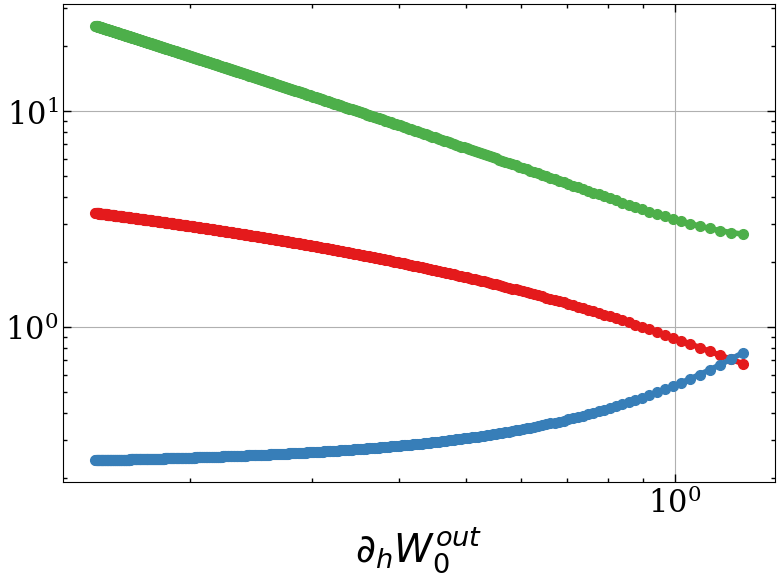

In [8]:
plt.plot(dWout_cont,K,'.-')
plt.plot(dWout_cont,I,'.-')
plt.loglog(dWout_cont,Omega,'.-')
plt.xlabel('$\partial_h W_0^{out}$')
plt.grid()

In [9]:
# Extrapolate the integrals I, K , Omega for the measured values of dW0out in the simulation taking the average between the closest values
# to compute the predicted value of v1 (for each time-step of the time simulation)
v1s = []
for j in np.arange(0,len(h0outs)):
    # Measurements from Time simulation
    h0out = h0outs[j]
    dW0out = dW0outs[j]
    A_droplet = As[j]
    nabla_x_h0out = grad_x_h0out[j]

    # Extrapolate the integrals I,K,Omega corresponding to the value of dW0out measured in the time simulation
    i = 1
    dW0out_temp = dWout_cont[-i]
    while dW0out > dW0out_temp and i < len(dWout_cont):
        i = i+1
        dW0out_temp = dWout_cont[-i]
    #dW0out_temp = (dW0out_temp + dWout_cont[-i+1])/2
    I_temp = (I[-i] + I[-i+1])/2
    K_temp = (K[-i] + K[-i+1])/2
    Omega_temp = (Omega[-i] + Omega[-i+1])/2
    # Here we consider only an inhomogenity and NOT a bulk force
    #nabla_x_h0out = 0
    v1 = 1/(3*eta*K_temp)*((-Omega_temp+dwetting_pot(h0out)*I_temp)*grad_chiA+I_temp*ddwetting_pot(h0out)*A_droplet*nabla_x_h0out/eps)
    v1s.append(v1)


# Validation of the model
$$\dot{\chi}_*=\epsilon^2 v_1\quad (69)$$
As $\chi=\epsilon x$, then $\dot{x}=\epsilon v_1$
$$\dot{x}/\epsilon = v_1$$

Text(0, 0.5, '$x_{max}$')

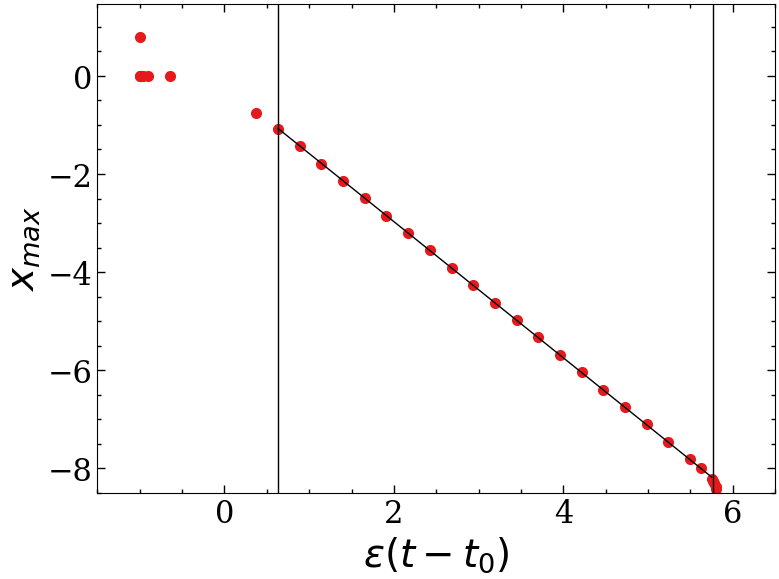

In [10]:
from matplotlib import pyplot as plt

# Measure of droplet position in the Time simulation
plt.plot((times-t0)*eps, x_at_hmax,'.')
imin = 10
imax = 32
plt.axvline((times[imin]-t0)*eps,color='black',lw='1')
plt.axvline((times[imax]-t0)*eps,color='black',lw='1')
tt = (times[imin:imax]-t0)*eps
xx = x_at_hmax[imin:imax]
c = np.polyfit(tt, xx, deg=1)
v1_time_simul = c[0]
plt.plot(tt, c[1]+c[0]*tt,color='black',lw='1')
plt.ylim(bottom=-8.5)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$x_{max}$')

Text(0, 0.5, '$v_{1}$')

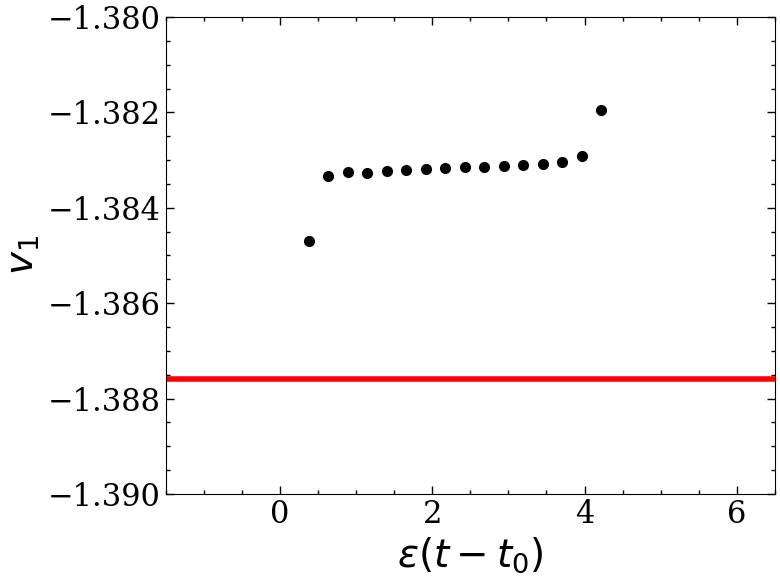

In [18]:
# Compare simulation with model
plt.plot(eps*(times-t0), v1s,'.',color='black')
plt.axhline(v1_time_simul,color='red')
plt.ylim(top=-1.38, bottom=-1.39)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$v_{1}$')